# Практическая работа №3: Интервальные оценки и критерий Пирсона
Выполнили студенты(-ки) гр. 2382 Вакуленко Инна и Ваньков Ярослав. Вариант №20

## Цель работы

Вычислить доверительные интервалы для математического ожидания и СКО, проверить гипотезу о нормальности распределения с помощью критерия χ².

## Основные теоретические положения


### 1. Доверительный интервал для математического ожидания

При **неизвестном** СКО используем **t-распределение (Стьюдента)**:

$$\bar{x} - \varepsilon \leq \mu \leq \bar{x} + \varepsilon$$

где точность:

$$\varepsilon = t_{\gamma, n-1} \cdot \frac{s}{\sqrt{n}}$$

$t_{\gamma, n-1}$ — критическое значение t-распределения при надёжности $\gamma$ и $n-1$ степенях свободы.


### 2. Доверительный интервал для СКО

Используем **χ²-распределение** для нахождения границ ДИ для СКО:

$$s\sqrt{\frac{n-1}{\chi^2_{right}}} \leq \sigma \leq s\sqrt{\frac{n-1}{\chi^2_{left}}}$$

где $\chi^2_{left}$ и $\chi^2_{right}$ — квантили χ²-распределения с $n-1$ степенями свободы.

Также находим параметр $q$ для симметричного представления:

$$\sigma \in \left(s(1-q),\ s(1+q)\right)$$


### 3. Проверка гипотезы о нормальности (критерий Пирсона χ²)

**H₀:** Случайная величина имеет нормальное распределение N(x̄, s²).

**H₁:** Распределение не является нормальным.

**Алгоритм:**
1. Разбиваем выборку на k интервалов.
2. Считаем наблюдаемые частоты $n_i$.
3. Находим теоретические вероятности $p_i$ через функцию Лапласа.
4. Находим теоретические частоты $n'_i = n \cdot p_i$.
5. Вычисляем наблюдаемое значение критерия: $\chi^2_{набл} = \sum \frac{(n_i - n'_i)^2}{n'_i}$
6. Сравниваем с критической точкой $\chi^2_{крит}$ при $df = k - 3$ и $\alpha = 0.05$.

**Правило вывода:**
- Если $\chi^2_{набл} < \chi^2_{крит}$ → H₀ **принимается** (нормальность подтверждена).
- Если $\chi^2_{набл} \geq \chi^2_{крит}$ → H₀ **отвергается**.


## Постановка задачи

В данной лабораторной работе нам необходимо проанализировать выборку (значения признака из 2-й практической работы).
Что нужно сделать:
1. Вычислить точечные оценки (выборочное среднее и исправленное СКО).
2. Найти доверительные интервалы для математического ожидания (СКО неизвестно, поэтому используем критерий Стьюдента) с надежностью 95% и 99%.
3. Найти доверительные интервалы для СКО с помощью χ² (хи-квадрат) распределения для тех же уровней надежности.
4. Проверить гипотезу о том, что наша выборка имеет нормальное распределение. Для этого посчитать эмпирические и теоретические частоты, заполнить расчетную таблицу, найти наблюдаемое значение критерия Пирсона и сравнить его с критическим.
5. Сделать выводы.


## Выполнение работы

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import os

# Настройка отображения таблиц
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [3]:
csv_path = "sample_120.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(f"\nКолонки: {df.columns.tolist()}")
print(f"Размер: {df.shape}")

   sepal_length  sepal_width
0        5.2000       3.4000
1        4.6000       3.4000
2        5.9000       3.2000
3        6.0000       2.2000
4        4.9000       2.4000

Колонки: ['sepal_length', 'sepal_width']
Размер: (120, 2)


In [4]:
data = df["sepal_length"].dropna().values

n        = len(data)
x_mean   = np.mean(data)
s        = np.std(data, ddof=1)
s2       = np.var(data, ddof=1)

print(f"Объём выборки:          n  = {n}")
print(f"Выборочное среднее:     x̄  = {x_mean:.4f}")
print(f"Исправленное СКО:       s  = {s:.4f}")
print(f"Выборочная дисперсия:   s² = {s2:.4f}")
print(f"Минимум:                   = {data.min():.4f}")
print(f"Максимум:                  = {data.max():.4f}")

Объём выборки:          n  = 120
Выборочное среднее:     x̄  = 5.8058
Исправленное СКО:       s  = 0.8313
Выборочная дисперсия:   s² = 0.6911
Минимум:                   = 4.3000
Максимум:                  = 7.7000


In [5]:
gammas = [0.95, 0.99]

print("=" * 55)
print("ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ МО (t-распределение)")
print("=" * 55)

for gamma in gammas:
    alpha = 1 - gamma

    # Критическое значение t-распределения (двустороннее)
    t_crit = stats.t.ppf((1 + gamma) / 2, df=n-1)

    # Точность (полуширина интервала)
    epsilon = t_crit * s / np.sqrt(n)

    # Границы доверительного интервала
    lower = x_mean - epsilon
    upper = x_mean + epsilon

    print(f"\nНадёжность γ = {gamma}:")
    print(f"  t_крит (df={n-1})  = {t_crit:.4f}")
    print(f"  Точность ε         = {epsilon:.4f}")
    print(f"  Доверительный интервал: [{lower:.4f}; {upper:.4f}]")
    print(f"  Ширина интервала:       {2 * epsilon:.4f}")

ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ МО (t-распределение)

Надёжность γ = 0.95:
  t_крит (df=119)  = 1.9801
  Точность ε         = 0.1503
  Доверительный интервал: [5.6556; 5.9561]
  Ширина интервала:       0.3005

Надёжность γ = 0.99:
  t_крит (df=119)  = 2.6178
  Точность ε         = 0.1987
  Доверительный интервал: [5.6072; 6.0045]
  Ширина интервала:       0.3973


Вывод: С надёжностью γ=0.95 (0.99) генеральное МО попадает в указанные интервалы.

In [6]:
print("=" * 55)
print("ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СКО (χ²-распределение)")
print("=" * 55)

for gamma in gammas:
    alpha = 1 - gamma
    df_chi = n - 1  # Число степеней свободы

    # Квантили χ²-распределения (двустороннее)
    chi2_left  = stats.chi2.ppf(alpha / 2, df=df_chi)   # Левый квантиль
    chi2_right = stats.chi2.ppf(1 - alpha / 2, df=df_chi) # Правый квантиль

    # Границы ДИ для СКО
    lower_sigma = s * np.sqrt(df_chi / chi2_right)
    upper_sigma = s * np.sqrt(df_chi / chi2_left)

    # Параметр q (симметричное представление)
    q = (upper_sigma - lower_sigma) / (2 * s)

    print(f"\nНадёжность γ = {gamma}:")
    print(f"  χ²_left  (df={df_chi}) = {chi2_left:.4f}")
    print(f"  χ²_right (df={df_chi}) = {chi2_right:.4f}")
    print(f"  ДИ для σ: [{lower_sigma:.4f}; {upper_sigma:.4f}]")
    print(f"  Параметр q             = {q:.4f}")
    print(f"  Симметричный ДИ: ({s*(1-q):.4f}; {s*(1+q):.4f})")

ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СКО (χ²-распределение)

Надёжность γ = 0.95:
  χ²_left  (df=119) = 90.6996
  χ²_right (df=119) = 151.0844
  ДИ для σ: [0.7378; 0.9523]
  Параметр q             = 0.1290
  Симметричный ДИ: (0.7241; 0.9386)

Надёжность γ = 0.99:
  χ²_left  (df=119) = 83.0182
  χ²_right (df=119) = 162.4815
  ДИ для σ: [0.7115; 0.9953]
  Параметр q             = 0.1707
  Симметричный ДИ: (0.6894; 0.9733)


In [7]:
alpha_test = 0.05

# (k = количество интервалов по формуле Стёрджеса)
k = int(np.ceil(1 + 3.322 * np.log10(n)))
print(f"Число интервалов (формула Стёрджеса): k = {k}")

edges = np.linspace(data.min(), data.max(), k + 1)

# Подсчёт наблюдаемых частот
n_obs, _ = np.histogram(data, bins=edges)

# Теоретические вероятности (через нормальное распределение)
p_theor = []
for i in range(k):
    left  = (edges[i]   - x_mean) / s
    right = (edges[i+1] - x_mean) / s
    # Вероятность попасть в интервал
    p_i = stats.norm.cdf(right) - stats.norm.cdf(left)
    p_theor.append(p_i)
p_theor = np.array(p_theor)

# Теоретические частоты
n_theor = n * p_theor

# Вычисление χ² набл
chi2_obs_terms = (n_obs - n_theor) ** 2 / n_theor
chi2_obs = chi2_obs_terms.sum()

df_table = pd.DataFrame({
    'i': range(1, k + 1),
    'Интервал [xi, xi+1)': [f'[{edges[i]:.3f}, {edges[i+1]:.3f})' for i in range(k)],
    'ni (набл)': n_obs,
    'pi': p_theor.round(4),
    "n'i (теор)": n_theor.round(4),
    '(ni-ni\')²': ((n_obs - n_theor)**2).round(4),
    '(ni-ni\')²/ni\'': chi2_obs_terms.round(4),
    'ni²': (n_obs**2),
    'ni²/ni\'': (n_obs**2 / n_theor).round(4)
})

sums = pd.DataFrame({
    'i': ['Σ'],
    'Интервал [xi, xi+1)': ['-'],
    'ni (набл)': [n_obs.sum()],
    'pi': [p_theor.sum().round(4)],
    "n'i (теор)": [n_theor.sum().round(4)],
    '(ni-ni\')²': [((n_obs - n_theor)**2).sum().round(4)],
    '(ni-ni\')²/ni\'': [chi2_obs_terms.sum().round(4)],
    'ni²': ['-'],
    'ni²/ni\'': [(n_obs**2 / n_theor).sum().round(4)]
})

full_table = pd.concat([df_table, sums], ignore_index=True)

print("\nТАБЛИЦА №1 (Расчётная)")
print(full_table.to_string(index=False))

# 7. Критическая точка
df_chi2 = k - 3  # Степени свободы: k - 1 - 2 (оцениваем МО и СКО)
chi2_crit = stats.chi2.ppf(1 - alpha_test, df=df_chi2)

print("\n" + "=" * 55)
print("ИТОГИ ПРОВЕРКИ ГИПОТЕЗЫ")
print("=" * 55)
print(f"  Уровень значимости:     α  = {alpha_test}")
print(f"  Число степеней свободы: df = k - 3 = {k} - 3 = {df_chi2}")
print(f"  χ²_набл                    = {chi2_obs:.4f}")
print(f"  χ²_крит (α={alpha_test}, df={df_chi2}) = {chi2_crit:.4f}")

Число интервалов (формула Стёрджеса): k = 8

ТАБЛИЦА №1 (Расчётная)
i Интервал [xi, xi+1)  ni (набл)     pi  n'i (теор)  (ni-ni')²  (ni-ni')²/ni' ni²  ni²/ni'
1      [4.300, 4.725)          9 0.0617      7.4086     2.5327         0.3419  81  10.9333
2      [4.725, 5.150)         26 0.1183     14.1969   139.3133         9.8129 676  47.6160
3      [5.150, 5.575)         16 0.1755     21.0654    25.6578         1.2180 256  12.1527
4      [5.575, 6.000)         20 0.2017     24.2039    17.6724         0.7301 400  16.5263
5      [6.000, 6.425)         20 0.1795     21.5352     2.3570         0.1094 400  18.5742
6      [6.425, 6.850)         16 0.1236     14.8374     1.3517         0.0911 256  17.2537
7      [6.850, 7.275)          7 0.0660      7.9156     0.8383         0.1059  49   6.1903
8      [7.275, 7.700)          6 0.0272      3.2695     7.4554         2.2803  36  11.0107
Σ                   -        120 0.9536    114.4324   197.1787        14.6897   - 140.2573

ИТОГИ ПРОВЕРКИ ГИПОТЕ

χ²_набл (14.6897) ≥ χ²_крит (11.0705)
H₀ ОТВЕРГАЕТСЯ. Нет оснований считать распределение нормальным

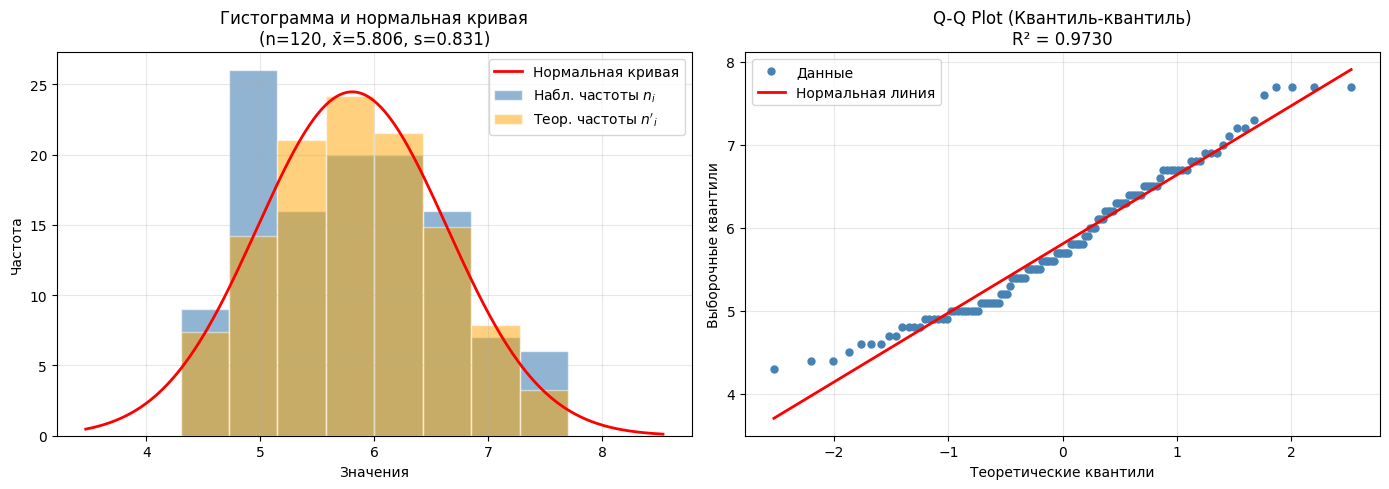

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма + Нормальная кривая
ax1 = axes[0]
ax1.bar(
    edges[:-1], n_obs, width=np.diff(edges),
    align='edge', alpha=0.6, color='steelblue',
    edgecolor='white', label='Набл. частоты $n_i$'
)
ax1.bar(
    edges[:-1], n_theor, width=np.diff(edges),
    align='edge', alpha=0.5, color='orange',
    edgecolor='white', label="Теор. частоты $n'_i$"
)

# Теоретическая кривая нормального распределения
x_line = np.linspace(data.min() - s, data.max() + s, 300)
y_line = stats.norm.pdf(x_line, x_mean, s) * n * np.diff(edges).mean()
ax1.plot(x_line, y_line, 'r-', linewidth=2, label='Нормальная кривая')

ax1.set_title(f'Гистограмма и нормальная кривая\n(n={n}, x̄={x_mean:.3f}, s={s:.3f})')
ax1.set_xlabel('Значения')
ax1.set_ylabel('Частота')
ax1.legend()
ax1.grid(alpha=0.3)

# Q-Q Plot
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
ax2.plot(osm, osr, 'o', color='steelblue', markersize=5, label='Данные')
ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2, label='Нормальная линия')
ax2.set_title(f'Q-Q Plot (Квантиль-квантиль)\nR² = {r**2:.4f}')
ax2.set_xlabel('Теоретические квантили')
ax2.set_ylabel('Выборочные квантили')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы

1. **Оценка математического ожидания:**
Посчитали доверительные интервалы для среднего значения выборки с помощью t-распределения, так как дисперсия генеральной совокупности нам неизвестна. Получилось, что при надежности $\gamma = 0.95$ интервал равен [5.6556; 5.9561], а при повышении надежности до $\gamma = 0.99$ интервал ожидаемо расширился до [5.6072; 6.0045]. То есть, чтобы быть более уверенными (99%) в том, что мы "поймали" истинное среднее, нам пришлось взять более широкие границы.

2. **Оценка СКО:**
Аналогичная ситуация и с доверительным интервалом для СКО (считали через распределение хи-квадрат). При $\gamma = 0.95$ интервал составил [0.7378; 0.9523]. А для $\gamma = 0.99$ он расширился и составил [0.7115; 0.9953]. Доверительные интервалы получились несимметричными относительно точечной оценки, так как само распределение хи-квадрат несимметрично.

3. **Проверка гипотезы о нормальном распределении:**
Далее была выдвинута гипотеза $H_0$: наши данные распределены по нормальному закону.
Мы разбили данные на 8 интервалов (по формуле Стёрджеса), заполнили расчетную таблицу и сравнили наблюдаемые и теоретические частоты.
Расчет показал, что наблюдаемый критерий Пирсона $\chi^2_{набл} = 14.6897$.
Критическое значение для $\alpha = 0.05$ и числа степеней свободы $df = 5$ составило $\chi^2_{крит} = 11.0705$.
Так как $\chi^2_{набл} \geq \chi^2_{крит}$ (14.6897 > 11.0705), гипотеза $H_0$ **отвергается**.

Кроме того, по графикам (гистограмма и Q-Q plot) тоже видно, что данные не идеально ложатся на нормальную кривую — во втором интервале [4.725; 5.150) наблюдается сильный выброс эмпирической частоты (26) над теоретической (14.19). Это логично, потому что исходный датасет содержит данные о разных видах растений, и их признаки накладываются друг на друга, ломая идеальный "колокол" нормального распределения.
